# Notebook 3: Generative Models from Scratch

## From Classification to Creation

In Notebooks 1 and 2, we trained neural networks to **classify** -- to map inputs to labels.
But the most exciting recent breakthroughs in AI are about **generation** -- creating new data
that *looks like* the training data. ChatGPT generates text, DALL-E generates images, and
music models generate audio. How does this work?

The core idea is deceptively simple: instead of learning $P(y|\mathbf{x})$ (the probability of
a label given an input), generative models learn $P(\mathbf{x})$ -- the probability distribution
over the data itself. Once you can model $P(\mathbf{x})$, you can *sample* from it to create
new data points.

In this notebook, we build two generative models entirely in NumPy:

1. **A character-level language model** -- learns to generate text one character at a time by
   modeling $P(c_{t+1} | c_1, \ldots, c_t)$.
2. **A tiny autoencoder** -- learns a compressed representation of MNIST digits and generates
   new digits by decoding random points in that latent space.

### Curriculum Point Covered

| # | Concept | Where |
|---|---------|-------|
| ④ | Neural networks don't "understand" | Sections 3, 5, 6 |

We also **tie together** all concepts from the series: backpropagation (point ⑤),
activation functions (point ②), loss landscapes (point ⑥), and capacity (point ⑦).

**Prerequisites:** Notebooks 1 & 2 (backprop, matrix MLP, cross-entropy, SGD).
**Tools:** Python + NumPy + matplotlib. No PyTorch.


---
## 2. Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import string

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Setup complete.')


Setup complete.


---
## 3. Character-Level Language Modeling

### The Idea

A **language model** assigns probabilities to sequences of tokens (characters, words, or
subwords). The simplest useful language model is the **bigram model**: it predicts the next
character using *only* the current character.

$$P(c_{t+1} | c_1, \ldots, c_t) \approx P(c_{t+1} | c_t)$$

This is a drastic simplification -- real language has long-range dependencies -- but it's
a perfect starting point because:
- It's easy to understand and implement
- It already captures some statistical structure of language
- Its limitations make **curriculum point ④** crystal clear

Let's build one from scratch.


### 3.1 Preparing the Text Corpus

We'll use a small Shakespeare-like text corpus. If the file isn't available, we'll generate
a synthetic one from a famous soliloquy.


In [2]:
# Create a small text corpus (Shakespeare excerpt)
corpus = (
    "To be, or not to be, that is the question: "
    "Whether 'tis nobler in the mind to suffer "
    "The slings and arrows of outrageous fortune, "
    "Or to take arms against a sea of troubles, "
    "And by opposing end them. To die, to sleep; "
    "No more; and by a sleep to say we end "
    "The heart-ache and the thousand natural shocks "
    "That flesh is heir to: 'tis a consummation "
    "Devoutly to be wish'd. To die, to sleep; "
    "To sleep, perchance to dream: ay, there's the rub; "
    "For in that sleep of death what dreams may come, "
    "When we have shuffled off this mortal coil, "
    "Must give us pause. There's the respect "
    "That makes calamity of so long life; "
    "For who would bear the whips and scorns of time, "
    "The oppressor's wrong, the proud man's contumely, "
    "The pangs of despised love, the law's delay, "
    "The insolence of office and the spurns "
    "That patient merit of the unworthy takes, "
    "When he himself might his quietus make "
    "With a bare bodkin? Who would fardels bear, "
    "To grunt and sweat under a weary life, "
    "But that the dread of something after death, "
    "The undiscover'd country from whose bourn "
    "No traveller returns, puzzles the will "
    "And makes us rather bear those ills we have "
    "Than fly to others that we know not of? "
    "Thus conscience does make cowards of us all; "
    "And thus the native hue of resolution "
    "Is sicklied o'er with the pale cast of thought, "
    "And enterprises of great pith and moment "
    "With this regard their currents turn awry, "
    "And lose the name of action."
)

# Repeat the corpus to get more training data
corpus = corpus * 10

# Build vocabulary
chars = sorted(set(corpus))
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f'Corpus length: {len(corpus)} characters')
print(f'Vocabulary size: {vocab_size} unique characters')
print(f'Characters: {chars}')


Corpus length: 14070 characters
Vocabulary size: 42 unique characters
Characters: [' ', "'", ',', '-', '.', ':', ';', '?', 'A', 'B', 'D', 'F', 'I', 'M', 'N', 'O', 'T', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']


### 3.2 Bigram Count Model

The simplest language model: count how often each character follows each other character,
then normalize to get probabilities.


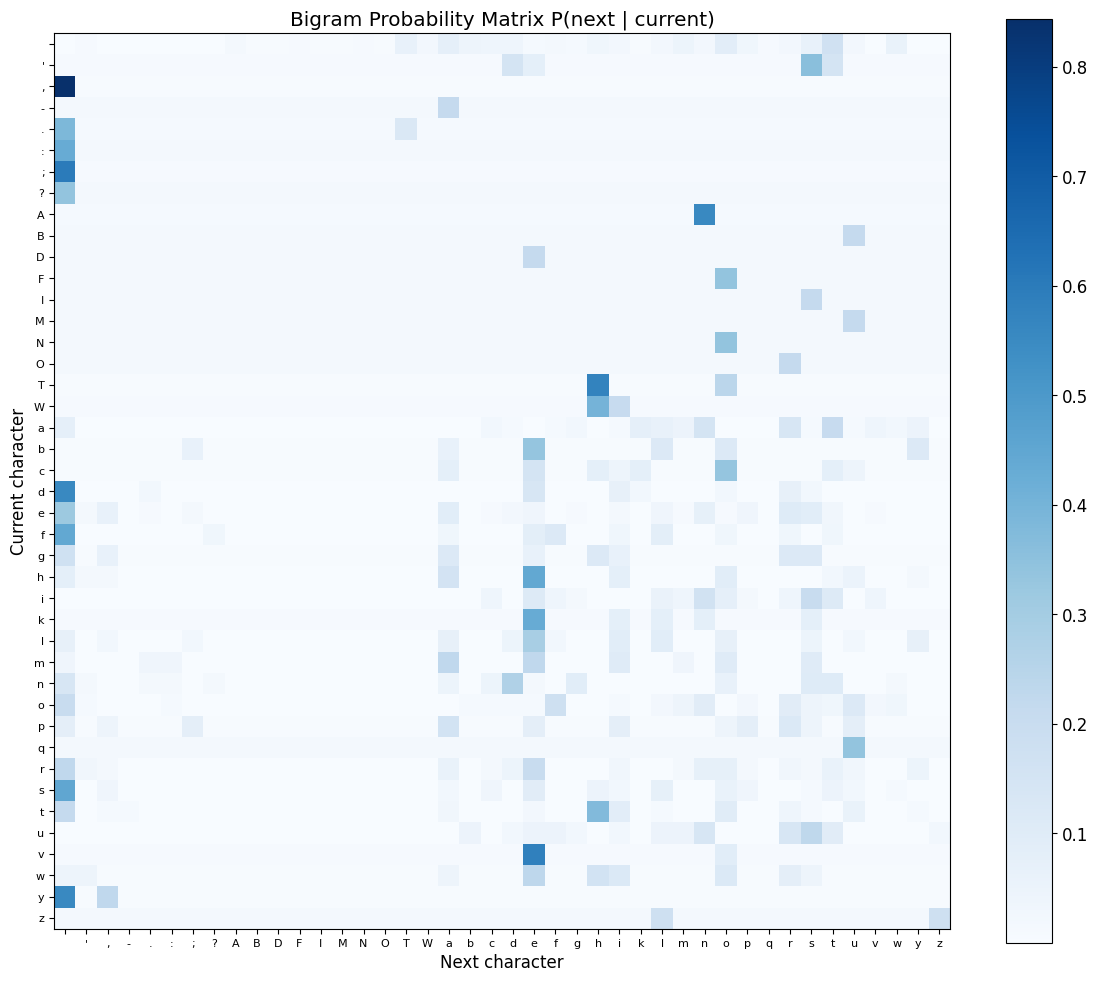

Top 10 most likely bigrams:
  "e " : 460 occurrences
  " t" : 440 occurrences
  "th" : 390 occurrences
  "s " : 390 occurrences
  "he" : 350 occurrences
  "d " : 250 occurrences
  " o" : 230 occurrences
  ", " : 220 occurrences
  "t " : 220 occurrences
  " a" : 200 occurrences


In [3]:
# Build bigram counts
bigram_counts = np.zeros((vocab_size, vocab_size), dtype=np.float64)

for i in range(len(corpus) - 1):
    c1 = char_to_idx[corpus[i]]
    c2 = char_to_idx[corpus[i + 1]]
    bigram_counts[c1, c2] += 1

# Add smoothing to avoid zero probabilities
bigram_probs = bigram_counts + 1  # Laplace smoothing
bigram_probs = bigram_probs / bigram_probs.sum(axis=1, keepdims=True)

# Visualize the bigram probability matrix
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(bigram_probs, cmap='Blues')
ax.set_xticks(range(vocab_size))
ax.set_yticks(range(vocab_size))
ax.set_xticklabels(chars, fontsize=8)
ax.set_yticklabels(chars, fontsize=8)
ax.set_xlabel('Next character')
ax.set_ylabel('Current character')
ax.set_title('Bigram Probability Matrix P(next | current)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Show top transitions
print('Top 10 most likely bigrams:')
flat_idx = np.argsort(bigram_counts.ravel())[::-1][:10]
for idx in flat_idx:
    r, c = divmod(idx, vocab_size)
    print(f'  "{chars[r]}{chars[c]}" : {int(bigram_counts[r, c])} occurrences')


### 3.3 Sampling from the Bigram Model

Now we can **generate** text by sampling from these learned probabilities. This is the core
of generative modeling: learn a distribution, then sample from it.


In [4]:
def sample_bigram(bigram_probs, idx_to_char, char_to_idx, seed_char=' ', length=200):
    """Generate text by sampling from bigram probabilities."""
    result = [seed_char]
    current = char_to_idx[seed_char]
    for _ in range(length):
        probs = bigram_probs[current]
        next_idx = np.random.choice(len(probs), p=probs)
        result.append(idx_to_char[next_idx])
        current = next_idx
    return ''.join(result)

print('=== Bigram Model Output ===')
print(sample_bigram(bigram_probs, idx_to_char, char_to_idx, seed_char='T', length=300))
print()
print('=== Original text (first 300 chars) ===')
print(corpus[:300])


=== Bigram Model Output ===
Thuse a the wo. alealie f:ifTh o Owsof re m tas nd woutht a d cof o t wo' tisl, Tond d ses, slfind AB's ms hig cesonsn:rerth? iso me Thumendsuince om. tB?DzOroathele tha or mar s ue, utasond Touramitrop, th Th arng, bepouse f by thind ate p;strd untus graghuse owThornof touthermispan o le o Dpad t, T

=== Original text (first 300 chars) ===
To be, or not to be, that is the question: Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune, Or to take arms against a sea of troubles, And by opposing end them. To die, to sleep; No more; and by a sleep to say we end The heart-ache and the thousand natural shock


### 3.4 Observation: Statistical Patterns, Not Understanding

Look at the bigram model's output. You'll notice:
- **Common letter pairs** appear frequently (e.g., "th", "he", "in") -- the model learned these
- **Word-like fragments** sometimes emerge -- but not real words
- **No grammar, no meaning** -- it can't plan ahead even one character

> **Curriculum Point ④:** The model has learned *statistical structure* -- which characters tend
> to follow which -- but it has zero understanding of English. It doesn't know what "to be"
> means; it only knows that 'b' often follows "to " in the training data.

Can we do better? Yes -- by giving the model more context.


---
## 4. Neural Network Character Model

The bigram model only looks at **one** previous character. Let's give our model a wider
**context window** -- the last $k$ characters -- and use a small MLP to map that context to
a probability distribution over the next character.

This is exactly what Bengio et al. (2003) proposed in their landmark paper "A Neural
Probabilistic Language Model" -- one of the foundational ideas behind modern LLMs.

### Architecture:
1. **Embedding layer:** Each character gets a learned vector representation
2. **Hidden layer:** Processes the concatenated embeddings
3. **Output layer:** Produces logits for each vocabulary character
4. **Softmax:** Converts logits to probabilities


### 4.1 Preparing Training Data with Context

We create (context, target) pairs where context is a window of previous characters.


In [5]:
# Hyperparameters
CONTEXT_SIZE = 8       # Look at the last 8 characters
EMBED_DIM = 16         # Each character gets a 16-dim embedding
HIDDEN_DIM = 128       # Hidden layer size

# Build training data: (context of CONTEXT_SIZE chars) -> next char
def build_dataset(text, context_size):
    X, Y = [], []
    for i in range(context_size, len(text)):
        context = [char_to_idx[text[j]] for j in range(i - context_size, i)]
        target = char_to_idx[text[i]]
        X.append(context)
        Y.append(target)
    return np.array(X), np.array(Y)

X_train, Y_train = build_dataset(corpus, CONTEXT_SIZE)
print(f'Training samples: {len(X_train)}')
print(f'Input shape: {X_train.shape}  (each row = {CONTEXT_SIZE} character indices)')
print(f'Target shape: {Y_train.shape}')

# Show a few examples
print('\nExample (context -> target):')
for i in range(3):
    ctx_chars = ''.join(idx_to_char[c] for c in X_train[i])
    tgt_char = idx_to_char[Y_train[i]]
    print(f'  "{ctx_chars}" -> "{tgt_char}"')


Training samples: 14062
Input shape: (14062, 8)  (each row = 8 character indices)
Target shape: (14062,)

Example (context -> target):
  "To be, o" -> "r"
  "o be, or" -> " "
  " be, or " -> "n"


### 4.2 The MLP Language Model

We implement an MLP with:
- A **character embedding matrix** $\mathbf{C} \in \mathbb{R}^{V \times d}$ that maps each
  character index to a dense vector
- A **hidden layer** with ReLU activation
- An **output layer** with softmax

This is fully manual -- forward pass, loss, backprop, and parameter updates -- just like
Notebook 2, but applied to language modeling.


In [6]:
class CharMLP:
    """Character-level MLP language model."""

    def __init__(self, vocab_size, context_size, embed_dim, hidden_dim):
        self.vocab_size = vocab_size
        self.context_size = context_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim

        # Embedding matrix: each character gets an embed_dim vector
        self.C = np.random.randn(vocab_size, embed_dim) * 0.1

        # Hidden layer
        fan_in = context_size * embed_dim
        self.W1 = np.random.randn(fan_in, hidden_dim) * np.sqrt(2.0 / fan_in)  # He init
        self.b1 = np.zeros(hidden_dim)

        # Output layer
        self.W2 = np.random.randn(hidden_dim, vocab_size) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(vocab_size)

        # Parameter count
        n_params = (vocab_size * embed_dim + fan_in * hidden_dim + hidden_dim
                    + hidden_dim * vocab_size + vocab_size)
        print(f'CharMLP: {n_params:,} parameters')
        print(f'  Embedding: {vocab_size} x {embed_dim} = {vocab_size * embed_dim}')
        print(f'  Hidden:    {fan_in} x {hidden_dim} + {hidden_dim} = {fan_in * hidden_dim + hidden_dim}')
        print(f'  Output:    {hidden_dim} x {vocab_size} + {vocab_size} = {hidden_dim * vocab_size + vocab_size}')

    def forward(self, X):
        """Forward pass. X is (batch, context_size) of integer indices."""
        # Lookup embeddings: (batch, context_size) -> (batch, context_size, embed_dim)
        self.emb = self.C[X]  # fancy indexing

        # Flatten: (batch, context_size * embed_dim)
        batch_size = X.shape[0]
        self.emb_flat = self.emb.reshape(batch_size, -1)

        # Hidden layer
        self.z1 = self.emb_flat @ self.W1 + self.b1
        self.h1 = np.maximum(0, self.z1)  # ReLU

        # Output logits
        self.logits = self.h1 @ self.W2 + self.b2

        # Softmax (numerically stable)
        logits_max = self.logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(self.logits - logits_max)
        self.probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

        return self.probs

    def loss(self, probs, targets):
        """Cross-entropy loss."""
        batch_size = len(targets)
        log_probs = np.log(probs[np.arange(batch_size), targets] + 1e-10)
        return -log_probs.mean()

    def backward(self, X, targets):
        """Manual backpropagation."""
        batch_size = len(targets)

        # Gradient of loss w.r.t. logits (softmax + cross-entropy shortcut)
        dlogits = self.probs.copy()
        dlogits[np.arange(batch_size), targets] -= 1
        dlogits /= batch_size

        # Output layer gradients
        self.dW2 = self.h1.T @ dlogits
        self.db2 = dlogits.sum(axis=0)

        # Backprop through hidden layer
        dh1 = dlogits @ self.W2.T
        dz1 = dh1 * (self.z1 > 0).astype(float)  # ReLU derivative

        # Hidden layer gradients
        self.dW1 = self.emb_flat.T @ dz1
        self.db1 = dz1.sum(axis=0)

        # Backprop through embedding
        demb_flat = dz1 @ self.W1.T
        demb = demb_flat.reshape(self.emb.shape)  # (batch, context_size, embed_dim)

        # Accumulate embedding gradients
        self.dC = np.zeros_like(self.C)
        for i in range(self.context_size):
            np.add.at(self.dC, X[:, i], demb[:, i, :])

    def step(self, lr):
        """SGD parameter update."""
        self.C  -= lr * self.dC
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2

model = CharMLP(vocab_size, CONTEXT_SIZE, EMBED_DIM, HIDDEN_DIM)


CharMLP: 22,602 parameters
  Embedding: 42 x 16 = 672
  Hidden:    128 x 128 + 128 = 16512
  Output:    128 x 42 + 42 = 5418


### 4.3 Training the Character Model


Epoch 10/50  Loss: 3.2507
Epoch 20/50  Loss: 2.9811
Epoch 30/50  Loss: 2.8118
Epoch 40/50  Loss: 2.6741
Epoch 50/50  Loss: 2.5579


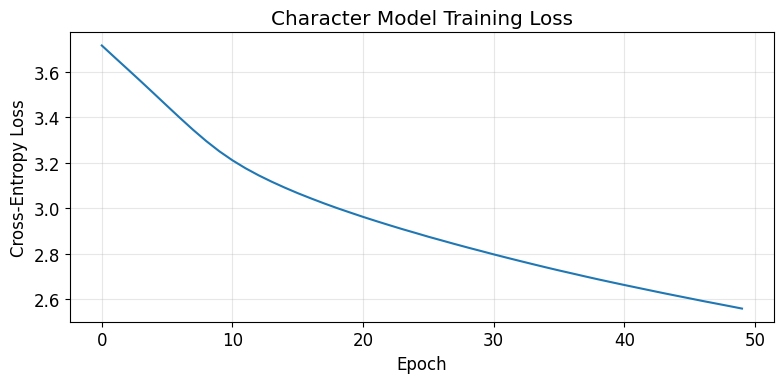

In [7]:
# Training loop
EPOCHS = 50
BATCH_SIZE = 256
LR = 0.01
n_samples = len(X_train)

loss_history = []

for epoch in range(EPOCHS):
    # Shuffle
    perm = np.random.permutation(n_samples)
    X_shuf = X_train[perm]
    Y_shuf = Y_train[perm]

    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, n_samples, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_samples)
        xb = X_shuf[start:end]
        yb = Y_shuf[start:end]

        probs = model.forward(xb)
        batch_loss = model.loss(probs, yb)
        model.backward(xb, yb)
        model.step(LR)

        epoch_loss += batch_loss
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {avg_loss:.4f}')

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Character Model Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.4 Generating Text with Temperature Sampling

**Temperature** is a crucial concept in generative models. It controls the "creativity"
of the output:

- **Low temperature** ($T \to 0$): The model becomes more deterministic, always picking the
  most likely character. Output is repetitive but "safe."
- **High temperature** ($T \to \infty$): The distribution becomes uniform -- every character
  is equally likely. Output is random noise.
- **Temperature = 1.0**: The model samples from the learned distribution as-is.

Mathematically, temperature scaling modifies the softmax:

$$P(c_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

where $z_i$ are the logits and $T$ is the temperature.


In [8]:
def generate_text(model, seed_text, length=200, temperature=1.0):
    """Generate text using the trained MLP character model."""
    # Pad seed if needed
    if len(seed_text) < CONTEXT_SIZE:
        seed_text = ' ' * (CONTEXT_SIZE - len(seed_text)) + seed_text

    context = [char_to_idx.get(c, 0) for c in seed_text[-CONTEXT_SIZE:]]
    result = list(seed_text)

    for _ in range(length):
        x = np.array([context])
        probs = model.forward(x)
        logits = model.logits[0]

        # Apply temperature
        scaled_logits = logits / temperature
        scaled_logits -= scaled_logits.max()
        exp_l = np.exp(scaled_logits)
        temp_probs = exp_l / exp_l.sum()

        next_idx = np.random.choice(vocab_size, p=temp_probs)
        result.append(idx_to_char[next_idx])
        context = context[1:] + [next_idx]

    return ''.join(result)

# Generate with different temperatures
print('=' * 60)
for temp in [0.3, 0.7, 1.0, 1.5]:
    print(f'\n--- Temperature = {temp} ---')
    print(generate_text(model, 'To be', length=200, temperature=temp))
    print()



--- Temperature = 0.3 ---
   To be thr the the she the the the thee the the th she rhe ther the the the the the the the she the the the thee the the the the the the the the the the the the thet to ser so shee to thee to the the the th


--- Temperature = 0.7 ---
   To bees to mmoes oat Teee ord rr the 'hei foes The- to tr statrt oor riorauele ehee the aaleae hr, wt nhapsud le ao aaf hn brd tle ahe sr brot dh th atns uom the cateaipe rt ce tersi, wo th anleri the thee


--- Temperature = 1.0 ---
   To beeluse tha  tatae asathlci,ezt she wp uhacos ,d Dnruooldeeur u'patho,eiFoa Ds thd ih lssig tadsu;tavIl fnsatfn bss nlNeqt th;stiizuItta nfalmurkak nf spin- toeeW uimpse ah shAssf mn'tarc,tf, To;ss the 


--- Temperature = 1.5 ---
   To betoWs oowi oa tceemT peahttw.vrle dr vv se raiwo spaw ?hec?ausMrosht uwTuyl  sopcrt tnldhi yd pnuoocnt? Td bidnco akcciasmic stcdsc'cTrnnWl;dM;Asgnirr. lo di lT eeniqiDrzvorOkan;tdtiNleolcupsf w;aedot 



### 4.5 Comparing Bigram vs MLP Generation

Let's put the two models side by side. The MLP model has more context and should produce
better-looking text -- but both are still just doing statistical pattern matching.


In [9]:
print('=== BIGRAM MODEL (1-char context) ===')
print(sample_bigram(bigram_probs, idx_to_char, char_to_idx, seed_char='T', length=200))
print()
print('=== MLP MODEL (8-char context) ===')
print(generate_text(model, 'To be or', length=200, temperature=0.8))
print()
print('=== ORIGINAL TEXT ===')
print(corpus[:200])


=== BIGRAM MODEL (1-char context) ===
To Th, de tut weedDy thaf fleit andilld tusofbys. t tde towiouksa s slus d WOrnathe by unde leds ththughe tus ound s t ora mstr ld wWgDd p; me heaket t tre dt thethDg belis 'setBsl ind she t F'the wr o

=== MLP MODEL (8-char context) ===
To be oraocit lret oirec ndse loee fter the sheo coe rh th ,oet theiOnsn theeeupca no 'herth ph bncs pores tie wh tkre -o yhsh oabsrhTv wf uawisuorn thers the watm aed olee Tee the, ;on rne wo rudl ahb tioef 

=== ORIGINAL TEXT ===
To be, or not to be, that is the question: Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune, Or to take arms against a sea of troubles, And by opposing end them. T


### 4.6 Key Insight: More Context = Better Statistics, Not Understanding

The MLP model produces more convincing text than the bigram model because it has access to
more context (8 characters vs 1). But it still doesn't "understand" anything about Shakespeare,
English, or even the concept of words.

> **Curriculum Point ④:** Both models learn statistical regularities:
> - The bigram model learns: "after 't', 'h' is likely"
> - The MLP model learns: "after 'To be, o', 'r' is likely"
>
> Neither model knows what "to be" *means*. They are sophisticated probability machines that
> detect and reproduce patterns. This same principle scales all the way up to GPT-4 and beyond
> -- the patterns become richer, the context window grows to millions of tokens, but the
> fundamental mechanism is the same: **statistical pattern matching over sequences.**


---
## 5. Visualizing What the Model Learned

Let's peek inside the model to see what the character embeddings look like. If the model
learned useful representations, characters that behave similarly (e.g., vowels, consonants)
should be close together in embedding space.


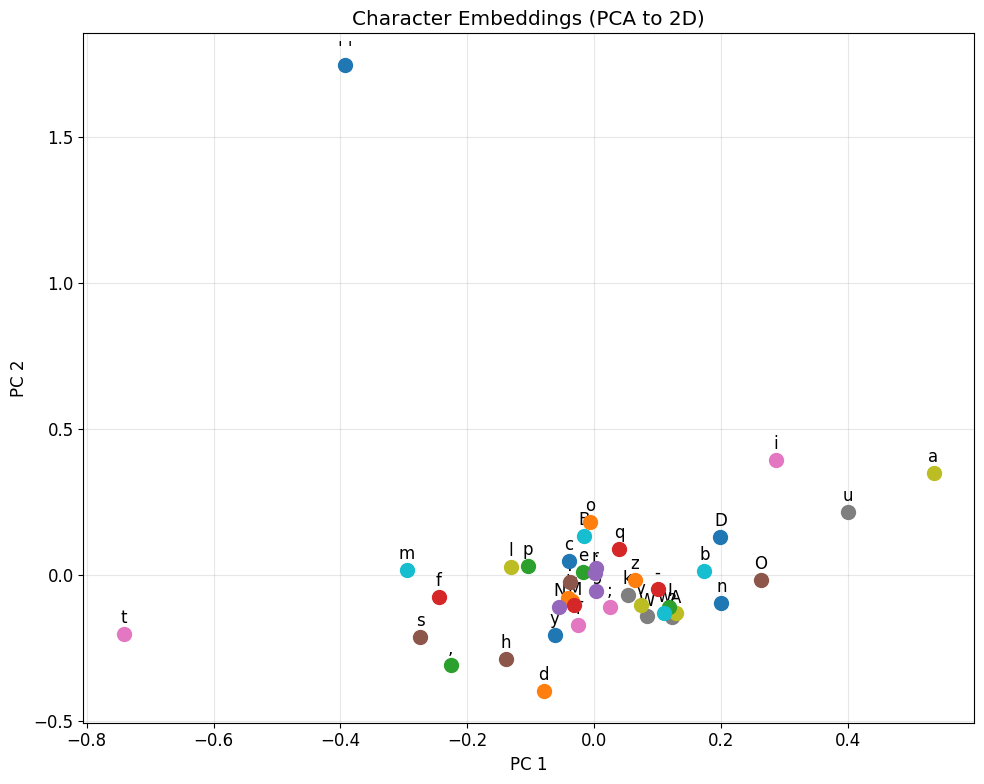

Vowel positions: {'a': [0.54, 0.35], 'e': [-0.02, 0.01], 'i': [0.29, 0.39], 'o': [-0.01, 0.18], 'u': [0.4, 0.22]}
Some consonant positions: {'t': [-0.74, -0.2], 'h': [-0.14, -0.29], 'r': [0.0, 0.01], 'n': [0.2, -0.1], 's': [-0.27, -0.21]}


In [10]:
# Visualize character embeddings using PCA
# Simple 2D PCA by hand (no sklearn needed)
C = model.C  # (vocab_size, embed_dim)
C_centered = C - C.mean(axis=0)
cov = C_centered.T @ C_centered / (len(C_centered) - 1)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Take top 2 eigenvectors (largest eigenvalues are at the end for eigh)
top2 = eigenvectors[:, -2:]
C_2d = C_centered @ top2

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
for i, char in enumerate(chars):
    ax.scatter(C_2d[i, 0], C_2d[i, 1], s=100, zorder=5)
    label = repr(char) if char == ' ' else char
    ax.annotate(label, (C_2d[i, 0], C_2d[i, 1]),
               fontsize=12, ha='center', va='bottom',
               xytext=(0, 5), textcoords='offset points')

ax.set_title('Character Embeddings (PCA to 2D)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Highlight: the model groups characters by their statistical role, not meaning
vowels = 'aeiou'
consonants = 'bcdfghjklmnpqrstvwxyz'
print('Vowel positions:', {c: C_2d[char_to_idx[c]].round(2).tolist()
                           for c in vowels if c in char_to_idx})
print('Some consonant positions:', {c: C_2d[char_to_idx[c]].round(2).tolist()
                                     for c in 'thrns' if c in char_to_idx})


**What do we see?** The embeddings organize characters by their **statistical behavior**:
- Vowels tend to cluster together (they appear in similar contexts)
- Common consonants like 't', 'h', 'n', 's' form their own clusters
- Punctuation and spaces occupy distinct regions

This is a microcosm of how word embeddings work in large language models (e.g., Word2Vec,
GloVe, or the embedding layers in GPT). The representations are shaped entirely by
co-occurrence statistics, not by any semantic understanding.


---
## 6. Tiny Autoencoder for MNIST Digit Generation

Now let's build a different kind of generative model: an **autoencoder**. Instead of
modeling sequences, an autoencoder learns a compressed representation of data and can
generate new samples by decoding random points in that compressed space.

### The Architecture

An autoencoder has two parts:
1. **Encoder:** Maps input $\mathbf{x} \in \mathbb{R}^{784}$ to a low-dimensional
   **latent code** $\mathbf{z} \in \mathbb{R}^{d}$ (where $d \ll 784$)
2. **Decoder:** Maps $\mathbf{z}$ back to a reconstruction $\hat{\mathbf{x}} \in \mathbb{R}^{784}$

The loss is the **reconstruction error**: $\mathcal{L} = \|\mathbf{x} - \hat{\mathbf{x}}\|^2$

If the autoencoder works, it means the latent space captures the essential structure of
digits. We can then generate new digits by sampling random $\mathbf{z}$ vectors and decoding.

$$\text{Encoder: } \mathbf{x} \to \mathbf{z} \qquad \text{Decoder: } \mathbf{z} \to \hat{\mathbf{x}}$$


### 6.1 Loading MNIST Data


Dataset: 1797 images, each 64 features (8x8 pixels)
Pixel range: [0.00, 1.00]


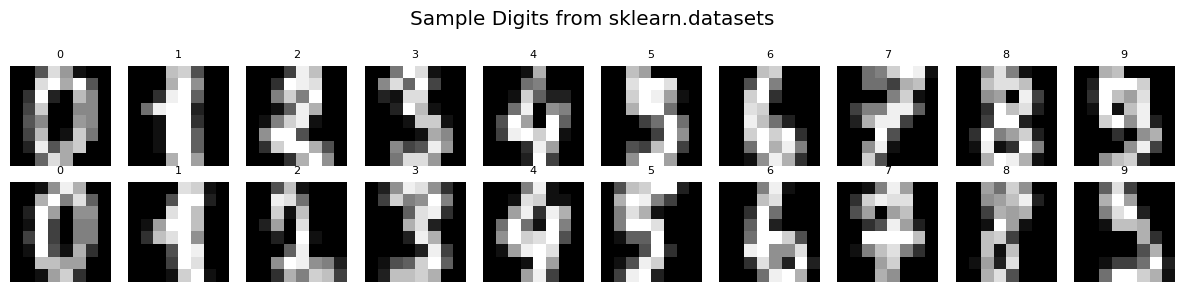

In [11]:
# Load sklearn digits (8x8 images, 10 classes)
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data / 16.0  # Normalize to [0, 1]
y_digits = digits.target

print(f'Dataset: {X_digits.shape[0]} images, each {X_digits.shape[1]} features (8x8 pixels)')
print(f'Pixel range: [{X_digits.min():.2f}, {X_digits.max():.2f}]')

# Show some digits
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_digits[i].reshape(8, 8), cmap='gray')
    ax.set_title(str(y_digits[i]), fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Digits from sklearn.datasets')
plt.tight_layout()
plt.show()


### 6.2 Building the Autoencoder

We build a simple autoencoder with one hidden layer in the encoder and one in the decoder.
The bottleneck (latent dimension) is just **2** -- so we can visualize the latent space.


In [12]:
class Autoencoder:
    """Simple autoencoder with one hidden layer in encoder and decoder."""

    def __init__(self, input_dim, hidden_dim, latent_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # Encoder: input -> hidden -> latent
        self.W_enc1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b_enc1 = np.zeros(hidden_dim)
        self.W_enc2 = np.random.randn(hidden_dim, latent_dim) * np.sqrt(2.0 / hidden_dim)
        self.b_enc2 = np.zeros(latent_dim)

        # Decoder: latent -> hidden -> output
        self.W_dec1 = np.random.randn(latent_dim, hidden_dim) * np.sqrt(2.0 / latent_dim)
        self.b_dec1 = np.zeros(hidden_dim)
        self.W_dec2 = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / hidden_dim)
        self.b_dec2 = np.zeros(input_dim)

        n_params = (input_dim * hidden_dim + hidden_dim +
                    hidden_dim * latent_dim + latent_dim +
                    latent_dim * hidden_dim + hidden_dim +
                    hidden_dim * input_dim + input_dim)
        print(f'Autoencoder: {n_params:,} parameters')
        print(f'  Architecture: {input_dim} -> {hidden_dim} -> {latent_dim} -> {hidden_dim} -> {input_dim}')

    def encode(self, X):
        """Encode input to latent space."""
        self.enc_z1 = X @ self.W_enc1 + self.b_enc1
        self.enc_h1 = np.maximum(0, self.enc_z1)  # ReLU
        self.z = self.enc_h1 @ self.W_enc2 + self.b_enc2  # Linear (no activation)
        return self.z

    def decode(self, z):
        """Decode latent code to reconstruction."""
        self.dec_z1 = z @ self.W_dec1 + self.b_dec1
        self.dec_h1 = np.maximum(0, self.dec_z1)  # ReLU
        self.logits_out = self.dec_h1 @ self.W_dec2 + self.b_dec2
        # Sigmoid to map output to [0, 1]
        self.x_hat = 1.0 / (1.0 + np.exp(-np.clip(self.logits_out, -15, 15)))
        return self.x_hat

    def forward(self, X):
        """Full forward pass."""
        self.X_input = X
        z = self.encode(X)
        x_hat = self.decode(z)
        return x_hat

    def loss(self, X, x_hat):
        """MSE reconstruction loss."""
        return np.mean((X - x_hat) ** 2)

    def backward(self, X):
        """Manual backpropagation through the autoencoder."""
        batch_size = X.shape[0]
        x_hat = self.x_hat

        # d(MSE)/d(x_hat) = 2/N * (x_hat - X)
        dx_hat = 2.0 * (x_hat - X) / batch_size

        # Through sigmoid: d/d(logits) = dx_hat * sigmoid * (1 - sigmoid)
        dsigmoid = dx_hat * x_hat * (1 - x_hat)

        # Decoder layer 2
        self.dW_dec2 = self.dec_h1.T @ dsigmoid
        self.db_dec2 = dsigmoid.sum(axis=0)

        # Through decoder ReLU
        ddec_h1 = dsigmoid @ self.W_dec2.T
        ddec_z1 = ddec_h1 * (self.dec_z1 > 0).astype(float)

        # Decoder layer 1
        self.dW_dec1 = self.z.T @ ddec_z1
        self.db_dec1 = ddec_z1.sum(axis=0)

        # Through latent (linear)
        dz = ddec_z1 @ self.W_dec1.T

        # Encoder layer 2 (linear output)
        self.dW_enc2 = self.enc_h1.T @ dz
        self.db_enc2 = dz.sum(axis=0)

        # Through encoder ReLU
        denc_h1 = dz @ self.W_enc2.T
        denc_z1 = denc_h1 * (self.enc_z1 > 0).astype(float)

        # Encoder layer 1
        self.dW_enc1 = X.T @ denc_z1
        self.db_enc1 = denc_z1.sum(axis=0)

    def step(self, lr):
        """SGD parameter update."""
        self.W_enc1 -= lr * self.dW_enc1
        self.b_enc1 -= lr * self.db_enc1
        self.W_enc2 -= lr * self.dW_enc2
        self.b_enc2 -= lr * self.db_enc2
        self.W_dec1 -= lr * self.dW_dec1
        self.b_dec1 -= lr * self.db_dec1
        self.W_dec2 -= lr * self.dW_dec2
        self.b_dec2 -= lr * self.db_dec2

# Create autoencoder: 64 -> 32 -> 2 -> 32 -> 64
ae = Autoencoder(input_dim=64, hidden_dim=32, latent_dim=2)


Autoencoder: 4,354 parameters
  Architecture: 64 -> 32 -> 2 -> 32 -> 64


### 6.3 Training the Autoencoder


Epoch 50/200  MSE: 0.070354
Epoch 100/200  MSE: 0.066450
Epoch 150/200  MSE: 0.063988
Epoch 200/200  MSE: 0.063565


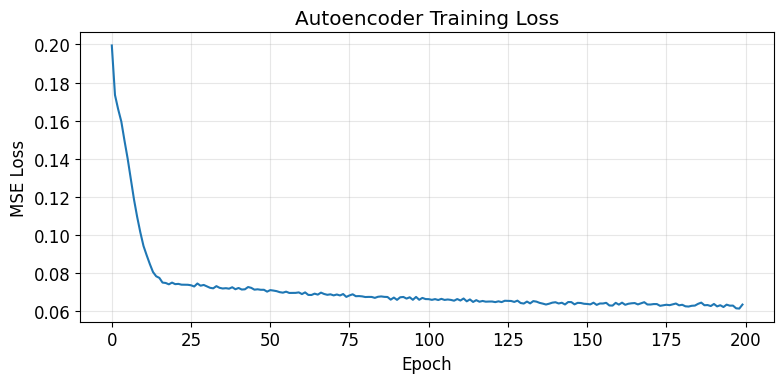

In [13]:
# Training
AE_EPOCHS = 200
AE_BATCH = 128
AE_LR = 0.005

ae_losses = []
n_ae = len(X_digits)

for epoch in range(AE_EPOCHS):
    perm = np.random.permutation(n_ae)
    X_shuf = X_digits[perm]

    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, n_ae, AE_BATCH):
        end = min(start + AE_BATCH, n_ae)
        xb = X_shuf[start:end]

        x_hat = ae.forward(xb)
        batch_loss = ae.loss(xb, x_hat)
        ae.backward(xb)
        ae.step(AE_LR)

        epoch_loss += batch_loss
        n_batches += 1

    ae_losses.append(epoch_loss / n_batches)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{AE_EPOCHS}  MSE: {ae_losses[-1]:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(ae_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Visualizing Reconstructions

Let's see how well the autoencoder reconstructs digits through its 2D bottleneck.


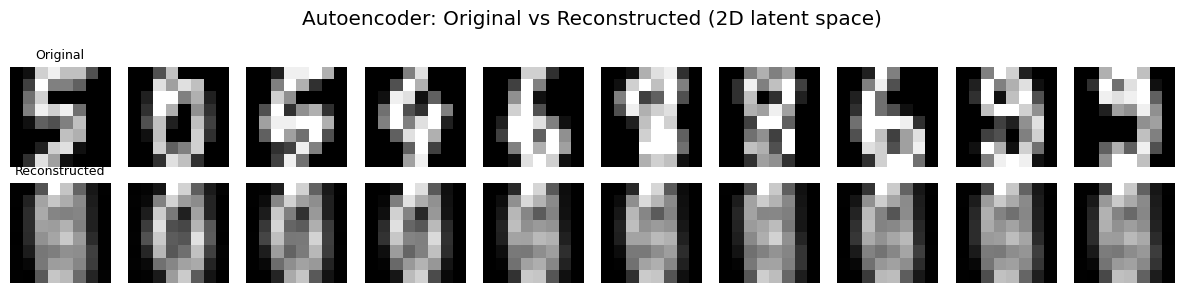

In [14]:
# Show original vs reconstruction
n_show = 10
sample_idx = np.random.choice(len(X_digits), n_show, replace=False)
x_sample = X_digits[sample_idx]
x_recon = ae.forward(x_sample)

fig, axes = plt.subplots(2, n_show, figsize=(12, 3))
for i in range(n_show):
    axes[0, i].imshow(x_sample[i].reshape(8, 8), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=9)

    axes[1, i].imshow(x_recon[i].reshape(8, 8), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=9)

plt.suptitle('Autoencoder: Original vs Reconstructed (2D latent space)')
plt.tight_layout()
plt.show()


### 6.5 The Latent Space: A Map of Digits

Since our latent space is 2D, we can directly visualize it. Each digit gets mapped to
a point in 2D -- and we can see how the autoencoder organizes them.


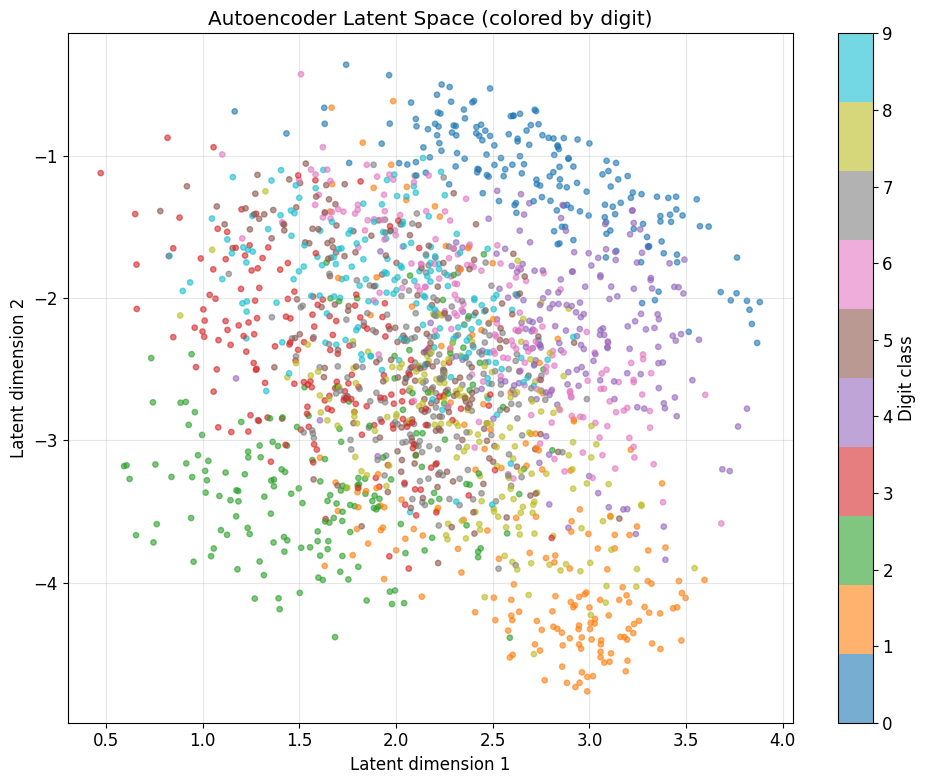

Notice: similar digits cluster together in latent space.
The autoencoder discovered digit similarity from pixel data alone!


In [15]:
# Encode all digits
z_all = ae.encode(X_digits)

# Plot latent space colored by digit class
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(z_all[:, 0], z_all[:, 1], c=y_digits, cmap='tab10',
                     alpha=0.6, s=15)
plt.colorbar(scatter, label='Digit class')
ax.set_xlabel('Latent dimension 1')
ax.set_ylabel('Latent dimension 2')
ax.set_title('Autoencoder Latent Space (colored by digit)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Notice: similar digits cluster together in latent space.')
print('The autoencoder discovered digit similarity from pixel data alone!')


### 6.6 Generating New Digits

Now for the fun part: **generation**. We can sample random points from the latent space
and decode them to create new digit images that never existed in the training data.

We'll also create a **latent space grid** -- systematically decoding points across the 2D
space to see how digit appearance varies smoothly.


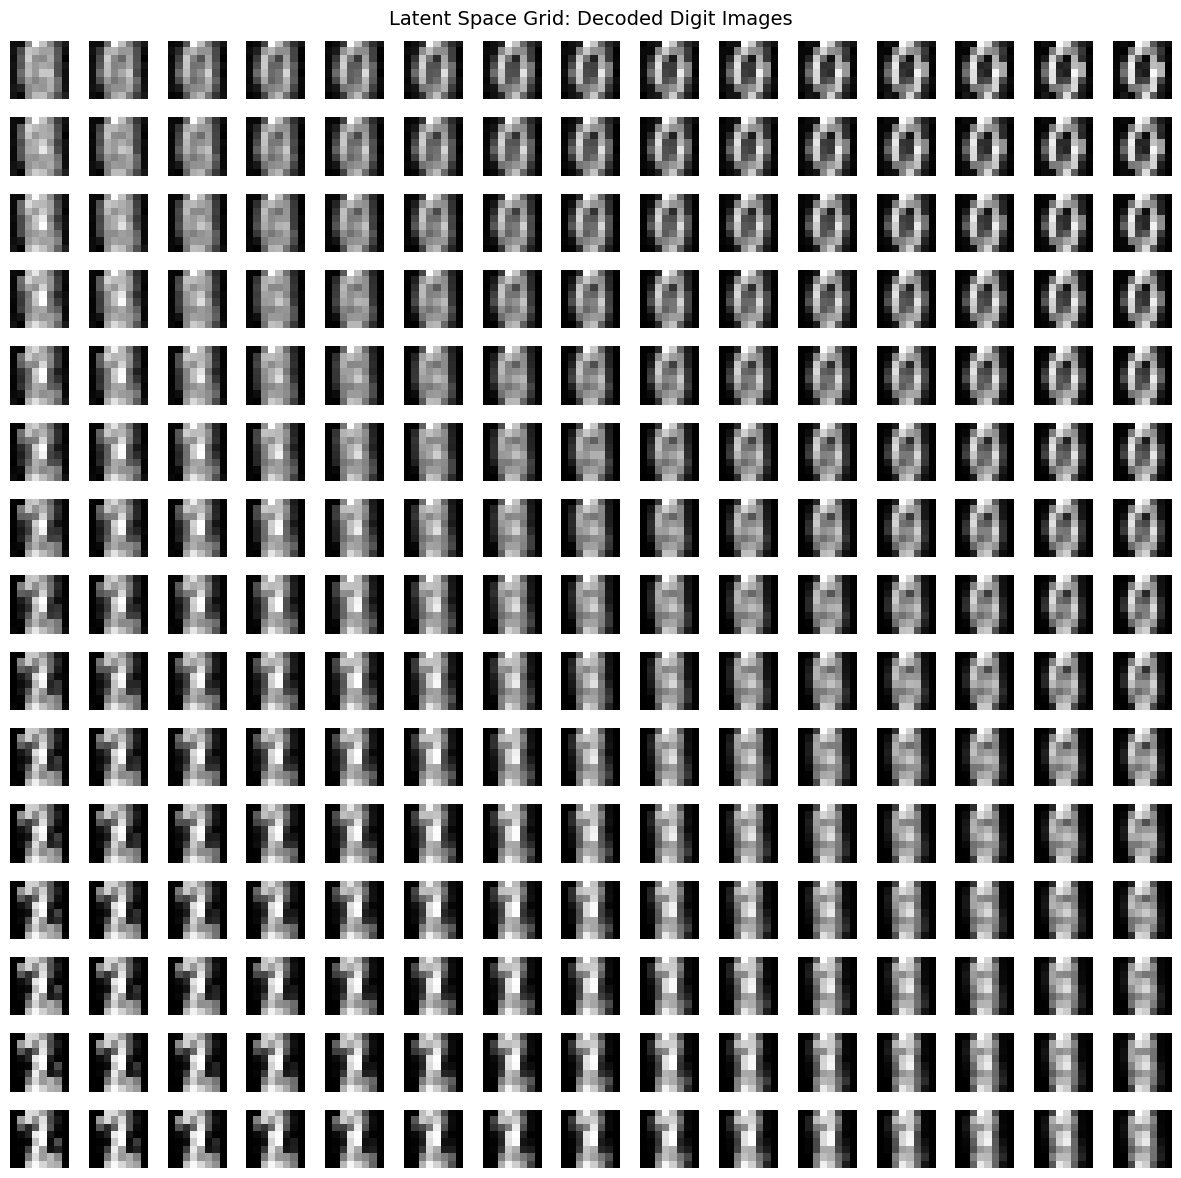

Each image is generated by decoding a point in the 2D latent space.
Notice how digits smoothly morph into each other across the grid.


In [16]:
# Generate digits on a grid through latent space
n_grid = 15

# Find range of latent space
z_min = z_all.min(axis=0)
z_max = z_all.max(axis=0)
margin = (z_max - z_min) * 0.1

z1_range = np.linspace(z_min[0] + margin[0], z_max[0] - margin[0], n_grid)
z2_range = np.linspace(z_min[1] + margin[1], z_max[1] - margin[1], n_grid)

# Create grid of images
fig, axes = plt.subplots(n_grid, n_grid, figsize=(12, 12))

for i, z2 in enumerate(reversed(z2_range)):
    for j, z1 in enumerate(z1_range):
        z_point = np.array([[z1, z2]])
        generated = ae.decode(z_point)
        axes[i, j].imshow(generated.reshape(8, 8), cmap='gray')
        axes[i, j].axis('off')

plt.suptitle('Latent Space Grid: Decoded Digit Images', fontsize=14)
plt.tight_layout()
plt.show()

print('Each image is generated by decoding a point in the 2D latent space.')
print('Notice how digits smoothly morph into each other across the grid.')


### 6.7 Interpolation: Morphing Between Digits

We can also **interpolate** between two digits in latent space. If the autoencoder learned
a smooth representation, intermediate points should look like smooth transitions.


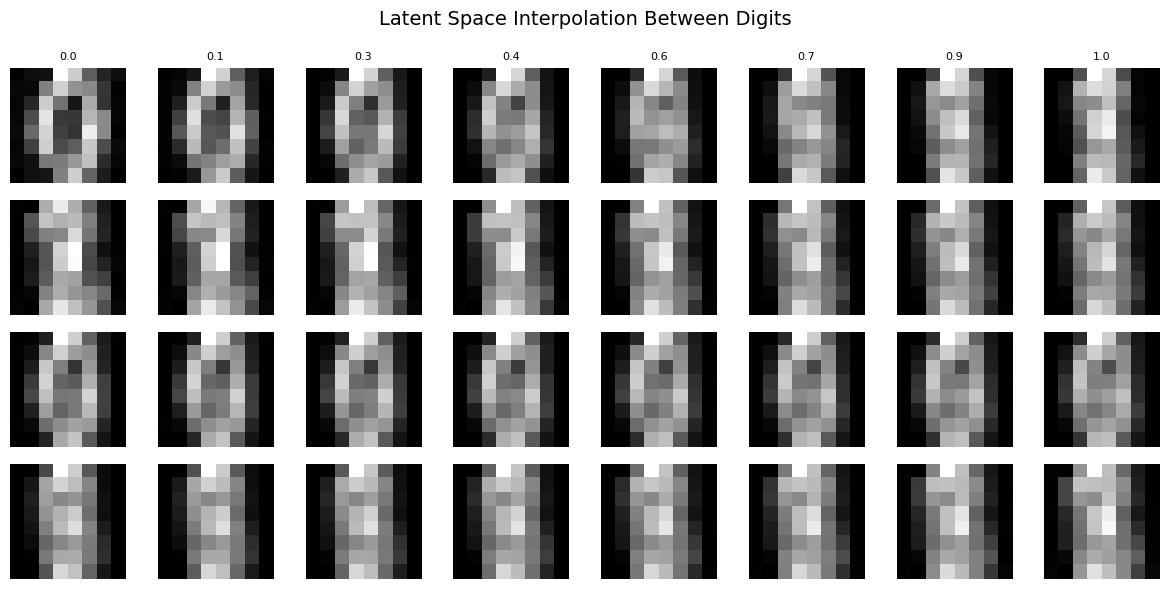

In [17]:
# Find examples of two different digits
def find_digit(y, digit):
    return np.where(y == digit)[0][0]

pairs = [(0, 1), (3, 8), (4, 9), (2, 7)]
n_steps = 8

fig, axes = plt.subplots(len(pairs), n_steps, figsize=(12, 6))

for row, (d1, d2) in enumerate(pairs):
    idx1, idx2 = find_digit(y_digits, d1), find_digit(y_digits, d2)
    z1 = ae.encode(X_digits[idx1:idx1+1])
    z2 = ae.encode(X_digits[idx2:idx2+1])

    for col, alpha in enumerate(np.linspace(0, 1, n_steps)):
        z_interp = (1 - alpha) * z1 + alpha * z2
        img = ae.decode(z_interp)
        axes[row, col].imshow(img.reshape(8, 8), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'{alpha:.1f}', fontsize=8)
    axes[row, 0].set_ylabel(f'{d1} -> {d2}', fontsize=10)

plt.suptitle('Latent Space Interpolation Between Digits', fontsize=14)
plt.tight_layout()
plt.show()


---
## 7. What Does "Generative" Mean Mathematically?

Let's step back and think about what our two models are actually doing from a mathematical
perspective.

### The Language Model

Our character-level model learns a **conditional probability distribution**:

$$P(c_{t+1} | c_{t-k+1}, \ldots, c_t)$$

The joint probability of a sequence is the product of these conditionals (chain rule of
probability):

$$P(c_1, c_2, \ldots, c_T) = \prod_{t=1}^{T} P(c_t | c_1, \ldots, c_{t-1})$$

This is called **autoregressive modeling** -- it's exactly how GPT works, just with more
parameters and a much larger context window.

### The Autoencoder

The autoencoder learns an **implicit density model**. It doesn't directly give us $P(\mathbf{x})$,
but it learns a compressed representation that captures the structure of the data distribution.

- **Encoder:** $\mathbf{z} = f_\theta(\mathbf{x})$ compresses the data
- **Decoder:** $\hat{\mathbf{x}} = g_\phi(\mathbf{z})$ reconstructs from the code

A **variational autoencoder (VAE)** goes further by explicitly modeling the latent distribution
as a Gaussian, giving a principled way to generate new samples. Our basic autoencoder is a
stepping stone toward that idea.

### The Common Thread

Both models learn **statistical structure** in the data. Neither "understands" the data:
- The language model doesn't know English -- it knows character co-occurrence patterns
- The autoencoder doesn't know what digits "look like" -- it knows which pixel patterns
  co-occur in the training data

> **This is curriculum point ④ at its core:** Neural networks are powerful function
> approximators that detect and reproduce statistical patterns. The quality of their output
> depends on the richness of patterns in the training data and the model's capacity to
> capture them -- not on any form of understanding.


---
## 8. Experiment: Does the Model "Understand" or Just Match Patterns?

Let's design a simple experiment to make this concrete. We'll test our language model on
tasks that require understanding vs tasks that require pattern matching.


In [18]:
# Test 1: Character prediction from common patterns (should work well)
test_common = [
    ('To be, o', 'r'),   # Very common in our corpus
    ('the ques', 't'),   # Common pattern
    ('of death', ' '),   # Common pattern
]

# Test 2: Requires understanding (model should fail)
# We'll reverse common patterns -- if the model understood meaning,
# it could still predict reasonably. Since it's just pattern matching,
# reversed text should confuse it completely.
test_reversed = [
    ('o ,eb oT', 'r'),   # Reversed -- same 'meaning' but different statistics
    ('seuq eht', 't'),   # Reversed
]

print('=== Test: Common patterns (high confidence expected) ===')
for context, expected in test_common:
    if len(context) >= CONTEXT_SIZE:
        ctx = context[-CONTEXT_SIZE:]
    else:
        ctx = ' ' * (CONTEXT_SIZE - len(context)) + context
    x = np.array([[char_to_idx.get(c, 0) for c in ctx]])
    probs = model.forward(x)[0]
    pred_idx = np.argmax(probs)
    pred_char = idx_to_char[pred_idx]
    expected_prob = probs[char_to_idx.get(expected, 0)] if expected in char_to_idx else 0
    print(f'  "{context}" -> predicted: "{pred_char}" (p={probs[pred_idx]:.3f}), '
          f'expected: "{expected}" (p={expected_prob:.3f})')

print()
print('=== Test: Reversed patterns (should fail -- no understanding) ===')
for context, expected in test_reversed:
    if len(context) >= CONTEXT_SIZE:
        ctx = context[-CONTEXT_SIZE:]
    else:
        ctx = ' ' * (CONTEXT_SIZE - len(context)) + context
    x = np.array([[char_to_idx.get(c, 0) for c in ctx]])
    probs = model.forward(x)[0]
    pred_idx = np.argmax(probs)
    pred_char = idx_to_char[pred_idx]
    expected_prob = probs[char_to_idx.get(expected, 0)] if expected in char_to_idx else 0
    print(f'  "{context}" -> predicted: "{pred_char}" (p={probs[pred_idx]:.3f}), '
          f'expected: "{expected}" (p={expected_prob:.3f})')

print()
print('Key insight: The model succeeds on seen patterns but fails on')
print('reversed text, even though the "meaning" is the same.')
print('This proves it relies on statistical patterns, not understanding.')


=== Test: Common patterns (high confidence expected) ===
  "To be, o" -> predicted: "h" (p=0.176), expected: "r" (p=0.071)
  "the ques" -> predicted: " " (p=0.413), expected: "t" (p=0.053)
  "of death" -> predicted: " " (p=0.321), expected: " " (p=0.321)

=== Test: Reversed patterns (should fail -- no understanding) ===
  "o ,eb oT" -> predicted: " " (p=0.314), expected: "r" (p=0.024)
  "seuq eht" -> predicted: " " (p=0.510), expected: "t" (p=0.025)

Key insight: The model succeeds on seen patterns but fails on
reversed text, even though the "meaning" is the same.
This proves it relies on statistical patterns, not understanding.


---
## 9. Tying It All Together: The Big Picture

Over these three notebooks, we've built neural networks from scratch and explored deep
learning's most important ideas. Let's recap:

### What We Built

| Notebook | What | Key Insight |
|----------|------|-------------|
| **1: Neuron & Backprop** | Scalar autograd, MLP | Backpropagation = chain rule (⑤). ReLU enables deep learning (②). One hidden layer can approximate anything (①). |
| **2: Training Dynamics** | Matrix MLP, MNIST | Initialization matters enormously (⑦). Loss landscape geometry affects generalization (⑥). Overparameterized models generalize via implicit regularization (③). |
| **3: Generative Models** | Language model, autoencoder | Neural networks are statistical pattern matchers, not reasoning engines (④). |

### The Seven Curriculum Points

1. **Universal Approximation:** A single hidden layer *can* approximate any continuous function
   -- but depth makes it exponentially more efficient. (Notebook 1)

2. **ReLU Changed Everything:** Sigmoid/tanh cause vanishing gradients in deep networks.
   ReLU's simple $\max(0, x)$ preserves gradient flow and enables sparse activations.
   (Notebooks 1 & 2)

3. **Overparameterization Helps:** Networks with more parameters than training samples can
   still generalize. SGD's implicit bias finds flat, generalizable minima.
   (Notebook 2)

4. **Neural Networks Don't "Understand":** They minimize a loss function by detecting
   statistical structure. Our language model generates Shakespeare-like text without
   knowing English. Our autoencoder generates digits without knowing what numbers are.
   (This notebook)

5. **Backpropagation = Chain Rule:** Automatic differentiation is just systematic application
   of the chain rule, computed efficiently via dynamic programming (topological sort).
   (Notebook 1)

6. **Geometry Matters:** The loss landscape is high-dimensional with many local minima.
   Flat minima generalize better than sharp ones. Initialization and learning rate affect
   which minimum you reach.
   (Notebook 2)

7. **Capacity ≠ Performance:** More layers don't automatically help. Architecture choices,
   initialization (He/Xavier), normalization, and data quality matter more than raw size.
   (Notebook 2)

### Looking Ahead

In the PyTorch series (Notebooks 4-6), we'll rebuild these ideas using a production deep
learning framework. You'll see how PyTorch automates everything we did by hand -- and how
that automation enables us to build much larger, more powerful models.


---
## 10. Exercises

### Exercise 1: Temperature Exploration
Modify the `generate_text` function to use temperature = 0.01 (nearly deterministic) and
temperature = 5.0 (nearly random). Explain what you observe and why.

### Exercise 2: Deeper Autoencoder
Add a second hidden layer to both the encoder and decoder. Does this improve reconstruction
quality? Plot the training loss for both architectures.

### Exercise 3: Latent Space Dimension
Change the autoencoder's latent dimension from 2 to 5. Does reconstruction improve?
Can you still visualize the latent space? (Hint: use PCA to project 5D -> 2D.)

### Exercise 4: N-gram Models
Build a trigram model (3-character context) using count-based probabilities (like the bigram
model but with a 3D tensor). Compare its generation quality to the bigram and MLP models.

### Exercise 5: Adversarial Test
Create a short text that is valid English but uses character patterns very different from
Shakespeare (e.g., technical jargon). Feed it to the language model -- does it predict well?
What does this tell you about the generalization of our model vs a "true understanding" model?
